# Gitterbasierte Post-Training-Quantisierung von Large Language Models

Begleitendes Notebook zur Bachelorarbeit.

## Hinweise zur Nutzung und Reproduzierbarkeit

## 1. Nur ansehen

Dafür ist **nichts nötig**. Auf GitHub lässt sich diese Datei direkt im
Browser lesen: Erklärtexte, Code, sämtliche Ausgaben und alle Abbildungen
sind mitgespeichert.

## 2. Selbst ausführen

Dafür muss das **gesamte Repository** heruntergeladen werden. Eine Möglichkeit ist über **Code → Download ZIP** und Entpacken. Die einzelne
`.ipynb`-Datei genügt nicht: Die Messdaten liegen als fünf eigene
JSON-Dateien daneben woraus die Abbildungen entstehen.

## 3. Messwerte neu erzeugen

Nur wer die Zahlen selbst nachrechnen will, setzt unten
`RUN_STUDIES = True`. Dann wird zusätzlich benötigt:

**Zugang zum Modell.** `meta-llama/Llama-3.2-1B` ist zugriffsbeschränkt. Nötig
ist ein Hugging-Face-Konto, das die Lizenz akzeptiert hat.

**Ein Token.** Das Notebook sucht ihn der Reihe nach in `token/hf_token.txt`,
in der Umgebungsvariablen `HF_TOKEN` und in einem gespeicherten
`huggingface-cli login`. Findet es keinen, fragt es ihn beim Ausführen ab.




## Konfiguration

Die folgende Zelle bestimmt den Datenordner aus dem Arbeitsverzeichnis des Kernels -- Jupyter startet
ihn im Ordner des Notebooks, dort liegen auch die JSON-Dateien.


In [1]:
import os
from pathlib import Path

# Studien neu rechnen? False = nur vorhandene Messdaten zeichnen.
RUN_STUDIES = False


DATEN = [
    "alpha_results.json",
    "dimension_study_results.json",
    "bitrate_study_results.json",
    "bitrate_study_nsm_results.json",
    "ppl_results.json",
]


def _finde_ordner():
    """Notebook-Ordner und Datenordner bestimmen.

    Jupyter startet den Kernel im Ordner des Notebooks; VS Code stellt den
    Pfad stattdessen in __vsc_ipynb_file__ bereit. Die Messdaten werden
    entweder direkt dort erwartet oder in einem Unterordner 'ergebnisse'.
    """
    kandidaten = []
    pfad_vscode = globals().get("__vsc_ipynb_file__")
    if pfad_vscode:
        kandidaten.append(Path(pfad_vscode).parent)
    kandidaten.append(Path.cwd())

    # Ordner mit den meisten passenden Dateien waehlen
    beste = None
    for hier in kandidaten:
        for daten in (hier, hier / "ergebnisse"):
            if not daten.is_dir():
                continue
            da = [f for f in DATEN if (daten / f).is_file()]
            if beste is None or len(da) > len(beste[2]):
                beste = (hier, daten, da)

    if beste and len(beste[2]) == len(DATEN):
        return beste[0].resolve(), beste[1].resolve()

    # --- ab hier: etwas stimmt nicht, moeglichst genau berichten ------------
    meldung = []
    if any(".zip" in str(k).lower() for k in kandidaten):
        meldung += [
            "ACHTUNG: Der Pfad enthaelt '.zip'. Vermutlich wurde das Notebook",
            "direkt aus einem Archiv heraus geoeffnet. Windows entpackt dabei",
            "nur diese eine Datei. Bitte das ZIP zuerst vollstaendig entpacken",
            "(Rechtsklick -> Alle extrahieren) und das Notebook danach aus dem",
            "entpackten Ordner oeffnen.",
            "",
        ]

    if beste is None or not beste[2]:
        meldung += [
            "Keine der erwarteten Messdatendateien gefunden.",
            "Gesucht in: " + ", ".join(str(k) for k in kandidaten),
            "sowie jeweils im Unterordner 'ergebnisse'.",
            "",
            "Erwartet werden diese fuenf Dateien neben dem Notebook:",
        ] + ["    " + f for f in DATEN]
        vorhanden = sorted(x.name for k in kandidaten if k.is_dir()
                           for x in k.glob("*.json"))
        meldung += ["", "Tatsaechlich vorhandene JSON-Dateien: "
                    + (", ".join(vorhanden) if vorhanden else "keine")]
    else:
        hier, daten, da = beste
        fehlt = [f for f in DATEN if f not in da]
        meldung += [
            "Die Messdaten sind unvollstaendig.",
            "Ordner: " + str(daten),
            "",
            "Gefunden (%d von %d):" % (len(da), len(DATEN)),
        ] + ["    " + f for f in da] + [
            "",
            "Es fehlen:",
        ] + ["    " + f for f in fehlt] + [
            "",
            "Weitere JSON-Dateien in diesem Ordner: "
            + (", ".join(sorted(x.name for x in daten.glob("*.json")
                                if x.name not in DATEN)) or "keine"),
        ]

    meldung += [
        "",
        "Alternativ die beiden Pfade in der naechsten Zeile von Hand setzen.",
    ]
    raise FileNotFoundError(chr(10).join(meldung))


BASE_DIR, DATA_DIR = (str(x) for x in _finde_ordner())

print("Notebook-Ordner:", BASE_DIR)
print("Messdaten      :", DATA_DIR)
print("Gefunden       :", sorted(f.name for f in Path(DATA_DIR).glob("*.json")))


Notebook-Ordner: C:\Users\giuse\Downloads\anpassen\Gitterbasierte-Post-Training-Quantisierung-von-Large-Language-Models-main
Messdaten      : C:\Users\giuse\Downloads\anpassen\Gitterbasierte-Post-Training-Quantisierung-von-Large-Language-Models-main
Gefunden       : ['alpha_results.json', 'bitrate_study_nsm_results.json', 'bitrate_study_results.json', 'dimension_study_results.json', 'ppl_results.json']


## Bibliotheken

In [2]:
import gc
import json
import time

import torch
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps, ticker

%matplotlib inline

# Nur für RUN_STUDIES = True nötig; Fehler hier ist ohne Studien unkritisch.
try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from datasets import load_dataset
    _ml_verfuegbar = True
except ImportError as exc:
    _ml_verfuegbar = False
    print("Hinweis:", exc)
    print("Zum Ansehen und Zeichnen der Abbildungen wird das nicht gebraucht.")
    print("Erst für RUN_STUDIES = True nötig:")
    print("    pip install transformers datasets accelerate")

C:\Users\giuse\Downloads\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## Rundungsfunktionen

In [3]:
# Hilfsfunktionen

def f_closest_integer(x):
    """
    f(x): rundet jede Koordinate auf die nächste ganze Zahl.
    """
    lower = torch.floor(x)
    frac = x - lower                      # in [0, 1)

    # Standardfall: zum näheren Nachbarn runden.
    rounded = torch.where(frac < 0.5, lower, lower + 1.0)

    # Grenzfall (frac == 0.5): Richtung 0.
    #   x >= 0 -> abrunden (lower);  x < 0 -> aufrunden (lower + 1 = ceil).
    tie = (frac == 0.5)
    toward_zero = torch.where(x >= 0, lower, lower + 1.0)
    rounded = torch.where(tie, toward_zero, rounded)
    return rounded

def g_wrong_rounding(x, fx):
    """
    g(x): identisch zu f(x), aber die "schlechteste" Koordinate wird in die
    FALSCHE Richtung gerundet.

    "Schlechteste" Koordinate = jene mit dem größten Rundungsfehler
    """
    delta = x - fx                                   # in [-1/2, 1/2]
    worst = delta.abs().argmax(dim=-1, keepdim=True)  # [B, 1]

    # Falsche Richtung: war abgerundet (delta >= 0) -> stattdessen +1,
    #                   war aufgerundet (delta < 0)  -> stattdessen -1.
    worst_delta = delta.gather(-1, worst)
    shift = torch.where(worst_delta >= 0,
                        torch.ones_like(worst_delta),
                        -torch.ones_like(worst_delta))

    gx = fx.clone()
    gx.scatter_add_(-1, worst, shift)   # ±1 nur auf die schlechteste Koordinate
    return gx

## Quantisierungsalgorithmen

In [4]:
# Quantisierungsalgorithmen

def quantize_zn(x):
   
    return f_closest_integer(x)

def quantize_dn(x):
    
    fx = f_closest_integer(x)
    gx = g_wrong_rounding(x, fx)

    fx_sum_odd = (fx.sum(dim=-1) % 2 != 0)            # [B] bool
    # f(x) hat gerade Summe -> f(x), sonst g(x).
    return torch.where(fx_sum_odd.unsqueeze(-1), gx, fx)

def quantize_an(x):
   
    B, d = x.shape
    device = x.device

    # Projektion auf Summe = 0.
    x_prime = x - x.sum(dim=-1, keepdim=True) / d

    # Runden + Defizit.
    fx_prime = f_closest_integer(x_prime)
    defect = fx_prime.sum(dim=-1).round().long()       # [B], Delta

    # Nach Rundungsfehler aufsteigend sortieren.
    errors = x_prime - fx_prime                         # delta_i in [-1/2, 1/2]
    sorted_idx = errors.argsort(dim=-1)                 # [B, d]

    # Korrekturvektor im SORTIERTEN Raum aufbauen.
    pos = torch.arange(d, device=device).unsqueeze(0)   # [1, d] Sortier-Rang
    delta_col = defect.unsqueeze(1)                      # [B, 1]

    #   Delta > 0: die ersten Delta Ränge (kleinste delta)  -> -1
    mask_sub = (pos < delta_col) & (delta_col > 0)
    #   Delta < 0: die letzten |Delta| Ränge (größte delta)  -> +1
    mask_add = (pos >= d + delta_col) & (delta_col < 0)

    # Pro Block tritt nur einer der Fälle auf -> kein Konflikt.
    corr_sorted = mask_add.to(x.dtype) - mask_sub.to(x.dtype)   # [B, d] in {-1,0,1}

    # Korrektur in den ursprünglichen Koordinatenraum zurückstreuen.
    corrections = torch.zeros_like(fx_prime)
    corrections.scatter_(1, sorted_idx, corr_sorted)

    # Ergebnis liegt in A_n: Summe ist exakt 0.
    return fx_prime + corrections


# Quantisierungs-Pipeline


In [5]:
# Quantisierungs-Pipeline für ganze Gewichtsmatrizen

def quantize_matrix(matrix, quant_func, n, scale, bits):
    """
    Quantisiert eine Matrix mit einem Gitter-Decoder. 
    """
    # Z_n ist die skalare Baseline: jede Koordinate wird unabhängig gerundet,
    # daher MUSS n=1 sein, damit der MSE sauber pro Element gemessen wird.
    if quant_func is quantize_zn:
        assert n == 1

    original_shape = matrix.shape
    original_dtype = matrix.dtype
    matrix = matrix.to(torch.float32)
    flat = matrix.flatten()
    num_original = flat.numel()

    # Auf ein Vielfaches der Blocklänge auffüllen.
    pad = (n - num_original % n) % n
    if pad > 0:
        flat = torch.cat([flat, torch.zeros(pad, device=flat.device)])
    blocks = flat.view(-1, n)

    min_bin = -(2 ** (bits - 1))
    max_bin = (2 ** (bits - 1)) - 1

    start = time.perf_counter()
    scaled = torch.clamp(blocks * scale, min_bin, max_bin)   # Clipping: Ausreißer auf die Bitgrenze

    if quant_func is quantize_an:
        # A_n projiziert auf Summe=0 und verliert dabei den Block-Mittelwert.
        # Mittelwert sichern und nach dem Decode zurückaddieren (Mittelwert-Erhalt).
        block_mean = scaled.mean(dim=-1, keepdim=True)
        q = quant_func(scaled) + block_mean
    else:
        q = quant_func(scaled)

    duration = time.perf_counter() - start

    dequant = (q / scale).flatten()[:num_original]   # zurückskalieren, Auffüllung weg
    mse = torch.mean((matrix.flatten() - dequant) ** 2).item()
    # Rückgabe im ursprünglichen Datentyp (meist bfloat16).
    return mse, duration, dequant.view(original_shape).to(original_dtype)

# Empirisches normiertes zweites Moment G_emp

def empirical_nsm(matrix, quant_func, n, scale, bits):
    """
    Empirische normierte Verzerrung (NSM) eines Layers:
    """
    mse, dur, _ = quantize_matrix(matrix, quant_func, n, scale, bits)

    # Volumen V und Gitter-Dimension je Gitter (n = Blocklänge, bei A_n um 1 größer):
    if quant_func is quantize_zn:
        vol, dim = 1.0, 1                        # Z: V = 1 (skalar)
    elif quant_func is quantize_dn:
        vol, dim = 2.0, n                        # D_n: V = 2, dim = n
    else:                                        # quantize_an
        vol, dim = n ** 0.5, n - 1               # A_n: V = √(n+1), dim = n

    # MSE ist pro Element (n Koordinaten); G_emp braucht den Fehler pro Dimension (dim).
    g = mse * (n / dim) * scale ** 2 / vol ** (2.0 / dim)
    return g, mse, dur

---
# Teil 3 — Die Messreihen

Ab hier wird das Sprachmodell benötigt. Die Funktionen werden immer definiert,
ausgeführt werden sie nur bei `RUN_STUDIES = True`.


In [6]:
import getpass


def _token_suchen():
    """Token aus Datei, Umgebung oder gespeichertem Login holen."""
    for datei in (os.path.join(BASE_DIR, "hf_token.txt"),
                  os.path.join(BASE_DIR, "token", "hf_token.txt")):
        if os.path.exists(datei):
            with open(datei, encoding="utf-8") as fh:
                tok = fh.read().strip()
            if tok and not tok.startswith("hf_HIER"):
                return tok, "aus " + os.path.basename(datei)
    if os.environ.get("HF_TOKEN"):
        return os.environ["HF_TOKEN"], "aus der Umgebungsvariablen HF_TOKEN"
    try:
        from huggingface_hub import get_token
        tok = get_token()
        if tok:
            return tok, "aus huggingface-cli login"
    except Exception:
        pass
    return None, None


_tok, _quelle = _token_suchen()

if _tok:
    os.environ["HF_TOKEN"] = _tok
    print("Token übernommen:", _quelle)
elif RUN_STUDIES:
    print("Kein Token gefunden. Er wird jetzt abgefragt.")
    print("Die Eingabe erscheint weder auf dem Bildschirm noch im gespeicherten")
    print("Notebook -- sie wird nur im Arbeitsspeicher dieser Sitzung gehalten.")
    os.environ["HF_TOKEN"] = getpass.getpass("Hugging-Face-Token: ").strip()
else:
    print("Kein Token gefunden -- für RUN_STUDIES = False wird auch keiner gebraucht.")
    print("Zum Nachrechnen genügt einer der drei Wege:")
    print("  huggingface-cli login   |   HF_TOKEN setzen   |   token/hf_token.txt")

Token übernommen: aus huggingface-cli login


## Der Skalierungsfaktor

In [7]:
MODEL_ID = "meta-llama/Llama-3.2-1B"

# Studie: optimalen Skalierungsfaktor K finden

def run_alpha_study(model_id=MODEL_ID,
                    bits=4,
                    n=16,
                    sigma_factors=(2.0, 2.5, 2.75, 3.0, 3.25,
                                   3.5, 3.75, 4.0, 4.5, 5.0)):
    """
    Findet je Methode (Z_n, D_n, A_n) den optimalen Sigma-Faktor k.
    """

    hf_token = os.environ.get("HF_TOKEN")
    output_dir = DATA_DIR
    os.makedirs(output_dir, exist_ok=True)

    print("--- Alpha-Studie: optimalen Sigma-Faktor k finden ---")
    model = AutoModelForCausalLM.from_pretrained(
        model_id, torch_dtype=torch.bfloat16, token=hf_token, device_map="cpu"
    )

    # Nur die quantisierbaren Linear-Layer (lm_head/embed_tokens sind sensibel).
    exclude = ["lm_head", "embed_tokens"]
    linear_layers = [
        m for name, m in model.named_modules()
        if isinstance(m, torch.nn.Linear) and not any(ex in name for ex in exclude)
    ]
    num_layers = len(linear_layers)
    print(f"Analysiere {num_layers} Layer...")

    methods = {"Z_n": quantize_zn, "D_n": quantize_dn, "A_n": quantize_an}
    max_bin = (2 ** (bits - 1)) - 1

    # {methode: {k: [mse je Layer]}}
    results = {m: {k: [] for k in sigma_factors} for m in methods}
    with torch.no_grad():
        for i, module in enumerate(linear_layers):
            weights = module.weight.data.detach().to(torch.float32)
            std = weights.std().item()
            for k in sigma_factors:
                scale = max_bin / (k * std)   # k*std wird auf max_bin abgebildet
                for m_name, func in methods.items():
                    # Blocklänge: Z_n skalar (1), D_n = n, A_n = n+1 Koordinaten.
                    block_n = 1 if func is quantize_zn else (n + 1 if func is quantize_an else n)
                    mse, _, _ = quantize_matrix(weights, func, block_n, scale, bits)
                    results[m_name][k].append(mse)
            if (i + 1) % 10 == 0:
                print(f"  Fortschritt: {i + 1}/{num_layers} Layer")

    # Mittel / Min / Max je (Methode, k) über die Layer (Min/Max für die Spannweite).
    stats = {}
    for m_name in methods:
        rows = []
        for k in sigma_factors:
            v = torch.tensor(results[m_name][k])
            rows.append({"k": k, "mean_mse": v.mean().item(),
                         "min_mse": v.min().item(), "max_mse": v.max().item()})
        stats[m_name] = rows

    with open(os.path.join(output_dir, "alpha_results.json"), "w") as fh:
        json.dump(stats, fh, indent=4)

    # Optimum je Methode: kleinster mittlerer MSE über die Sigma-Faktoren.
    optima = {}
    for m_name, rows in stats.items():
        df = pd.DataFrame(rows)
        opt_k = df.loc[df["mean_mse"].idxmin(), "k"]
        optima[m_name] = opt_k
        print(f"  {m_name}: optimales k = {opt_k}")

    print(f"Fertig. Ergebnisse in {output_dir}")

    return stats, optima

## Gitterdimension und Bitrate


In [8]:
# Optimale Sigma-Faktoren k je Methode (aus run_alpha_study ermittelt)
OPTIMAL_K = {"Z_n": 3.0, "D_n": 3.0, "A_n": 3.0}

# Studie: Gitter-Dimension vs. MSE und Rechenzeit

def run_dimension_study(bits=4,
                        dimensions=(2, 4, 8, 16, 32, 64, 128, 256, 512)):
    """
    Zentrales Experiment: Wie verändern sich MSE und Rechenzeit mit der
    Gitter-Dimension n?
    """

    k = OPTIMAL_K
    hf_token = os.environ.get("HF_TOKEN")
    output_dir = DATA_DIR
    os.makedirs(output_dir, exist_ok=True)

    print("--- Dimension vs. MSE & Zeit (Full Model) ---")
    model = AutoModelForCausalLM.from_pretrained(
        "meta-llama/Llama-3.2-1B", torch_dtype=torch.bfloat16,
        token=hf_token, device_map="cpu"
    )

    exclude = ["lm_head", "embed_tokens"]
    linear_layers = [
        (name, m) for name, m in model.named_modules()
        if isinstance(m, torch.nn.Linear) and not any(ex in name for ex in exclude)
    ]
    num_layers = len(linear_layers)
    print(f"{num_layers} Layer gefunden.")

    max_bin = (2 ** (bits - 1)) - 1
    results = []

    with torch.no_grad():
        for n in dimensions:
            print(f"\n>>> Dimension n={n} über {num_layers} Layer...")
            acc = {"Zn": [0.0, 0.0], "Dn": [0.0, 0.0], "An": [0.0, 0.0]}  # [G_emp, zeit]

            for name, module in linear_layers:
                w = module.weight.data.detach()
                std = w.to(torch.float32).std().item()
                # Jede Methode mit ihrem eigenen optimalen k -> eigener scale.
                s_z = max_bin / (k["Z_n"] * std)
                s_d = max_bin / (k["D_n"] * std)
                s_a = max_bin / (k["A_n"] * std)

                # G_emp pro Layer (skaleninvariant). Z^1 = skalare
                # Baseline (dimensionsunabhängig).
                gz, _, tz = empirical_nsm(w, quantize_zn, 1, s_z, bits)
                gd, _, td = empirical_nsm(w, quantize_dn, n, s_d, bits)
                ga, _, ta = empirical_nsm(w, quantize_an, n + 1, s_a, bits)
                acc["Zn"][0] += gz; acc["Zn"][1] += tz
                acc["Dn"][0] += gd; acc["Dn"][1] += td
                acc["An"][0] += ga; acc["An"][1] += ta

            results.append({
                "n": n,
                "G_Zn": acc["Zn"][0] / num_layers, "Zeit_Zn": acc["Zn"][1] / num_layers,
                "G_Dn": acc["Dn"][0] / num_layers, "Zeit_Dn": acc["Dn"][1] / num_layers,
                "G_An": acc["An"][0] / num_layers, "Zeit_An": acc["An"][1] / num_layers,
            })

    with open(os.path.join(output_dir, "dimension_study_results.json"), "w",
              encoding="utf-8") as fh:
        json.dump(results, fh, indent=4)

    print(f"Fertig. Ergebnisse in {output_dir}")

    return results

In [9]:
# Studie: Bitrate vs. MSE

def run_bitrate_study(model_id="meta-llama/Llama-3.2-1B",
                      output_dir=None,
                      bitrates=(2, 3, 4),
                      dimensions=(2, 4, 8, 16, 32, 64, 128, 256, 512),
                      k=None):
    """
    Vergleicht Z_n / D_n / A_n über die Bitrate via MSE.
    """

    if k is None:
        k = OPTIMAL_K
    hf_token = os.environ.get("HF_TOKEN")
    if output_dir is None:
        output_dir = DATA_DIR
    os.makedirs(output_dir, exist_ok=True)

    print("--- Bitrate vs. MSE ---")
    model = AutoModelForCausalLM.from_pretrained(
        model_id, torch_dtype=torch.bfloat16, token=hf_token, device_map="cpu"
    )
    exclude = ["lm_head", "embed_tokens"]
    weights = [m.weight.data.detach().to(torch.float32)
               for name, m in model.named_modules()
               if isinstance(m, torch.nn.Linear) and not any(ex in name for ex in exclude)]
    num_layers = len(weights)
    print(f"{num_layers} Layer gefunden.")

    # --- Messung: MSE je (b, Methode, n) ---
    # quantize_matrix gibt (MSE, Dauer, quantisierte_Matrix) zurück
    records = []
    with torch.no_grad():
        for b in bitrates:
            max_bin = (2 ** (b - 1)) - 1
            stds = [w.std().item() for w in weights]
            # Pro Methode eigener scale (eigenes optimales k).
            sc_z = [max_bin / (k["Z_n"] * sd) for sd in stds]
            sc_d = [max_bin / (k["D_n"] * sd) for sd in stds]
            sc_a = [max_bin / (k["A_n"] * sd) for sd in stds]

            mse_z = sum(quantize_matrix(w, quantize_zn, 1, s, b)[0]
                        for w, s in zip(weights, sc_z)) / num_layers
            records.append({"method": "Z_n", "n": 1, "b": b, "mse": mse_z})

            for n in dimensions:
                mse_d = sum(quantize_matrix(w, quantize_dn, n, s, b)[0]
                            for w, s in zip(weights, sc_d)) / num_layers
                mse_a = sum(quantize_matrix(w, quantize_an, n + 1, s, b)[0]
                            for w, s in zip(weights, sc_a)) / num_layers
                records.append({"method": "D_n", "n": n, "b": b, "mse": mse_d})
                records.append({"method": "A_n", "n": n, "b": b, "mse": mse_a})
            print(f"  Bitrate {b} Bit fertig.")

    with open(os.path.join(output_dir, "bitrate_study_results.json"), "w",
              encoding="utf-8") as fh:
        json.dump(records, fh, indent=4)

    print(f"Fertig. JSON in {output_dir}")
    return records

In [10]:
# Wie run_bitrate_study, misst aber G_emp statt des rohen MSE.
def run_bitrate_study_nsm(model_id="meta-llama/Llama-3.2-1B",
                          output_dir=None,
                          bitrates=(2, 3, 4),
                          dimensions=(2, 4, 8, 16, 32, 64),
                          k=None):
    

    if k is None:
        k = OPTIMAL_K
    hf_token = os.environ.get("HF_TOKEN")
    if output_dir is None:
        output_dir = DATA_DIR
    os.makedirs(output_dir, exist_ok=True)

    print("--- Bitrate vs. NSM ---")
    model = AutoModelForCausalLM.from_pretrained(
        model_id, torch_dtype=torch.bfloat16, token=hf_token, device_map="cpu"
    )
    exclude = ["lm_head", "embed_tokens"]
    weights = [m.weight.data.detach().to(torch.float32)
               for name, m in model.named_modules()
               if isinstance(m, torch.nn.Linear) and not any(ex in name for ex in exclude)]
    num_layers = len(weights)
    print(f"{num_layers} Layer gefunden.")

    # --- Messung: G_emp je (b, Methode, n) ---
    # empirical_nsm gibt (G_emp, MSE, Dauer) zurück
    records = []
    with torch.no_grad():
        for b in bitrates:
            max_bin = (2 ** (b - 1)) - 1
            stds = [w.std().item() for w in weights]
            # Pro Methode eigener scale (eigenes optimales k).
            sc_z = [max_bin / (k["Z_n"] * sd) for sd in stds]
            sc_d = [max_bin / (k["D_n"] * sd) for sd in stds]
            sc_a = [max_bin / (k["A_n"] * sd) for sd in stds]

            g_z = sum(empirical_nsm(w, quantize_zn, 1, s, b)[0]
                      for w, s in zip(weights, sc_z)) / num_layers
            records.append({"method": "Z_n", "n": 1, "b": b, "G_emp": g_z})

            for n in dimensions:
                g_d = sum(empirical_nsm(w, quantize_dn, n, s, b)[0]
                          for w, s in zip(weights, sc_d)) / num_layers
                g_a = sum(empirical_nsm(w, quantize_an, n + 1, s, b)[0]
                          for w, s in zip(weights, sc_a)) / num_layers
                records.append({"method": "D_n", "n": n, "b": b, "G_emp": g_d})
                records.append({"method": "A_n", "n": n, "b": b, "G_emp": g_a})
            print(f"  Bitrate {b} Bit fertig.")

    with open(os.path.join(output_dir, "bitrate_study_nsm_results.json"), "w",
              encoding="utf-8") as fh:
        json.dump(records, fh, indent=4)

    print(f"Fertig. JSON in {output_dir}")
    return records

## Perplexity


In [11]:
# Studie: Perplexity nach Quantisierung

def evaluate_ppl(model, tokenizer, max_length=2048, stride=512, dataset_limit=30, desc="PPL"):
    """
    Perplexity auf WikiText-2 (test) nach dem Standard-Sliding-Window-Rezept
    von Hugging Face.
    """
    

    max_length = min(max_length, model.config.max_position_embeddings)
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    text = [ln for ln in dataset["text"] if len(ln.strip()) > 0]
    enc = tokenizer("\n\n".join(text[:dataset_limit]), return_tensors="pt")
    seq_len = enc.input_ids.size(1)

    # Effektive Fensterzahl (die Schleife bricht ab, sobald ein Fenster das Ende
    # erreicht) — nur für die Fortschrittsanzeige.
    total_windows = 0
    for _b in range(0, seq_len, stride):
        total_windows += 1
        if min(_b + max_length, seq_len) == seq_len:
            break
    print(f"      [{desc}] PPL über {total_windows} Fenster (seq_len={seq_len}) ...",
          flush=True)

    nlls, prev_end = [], 0
    for win, begin in enumerate(range(0, seq_len, stride), start=1):
        end = min(begin + max_length, seq_len)
        trg_len = end - prev_end                       # neu zu bewertende Token
        input_ids = enc.input_ids[:, begin:end].to(model.device)
        target_ids = input_ids.clone()
        target_ids[:, :-trg_len] = -100                # Kontext-Token maskieren

        with torch.no_grad():
            out = model(input_ids, labels=target_ids)
            nlls.append(out.loss * trg_len)

        print(f"      [{desc}] Fenster {win}/{total_windows}", end="\r", flush=True)
        prev_end = end
        if end == seq_len:
            break

    print()  # Zeilenumbruch nach der \r-Fortschrittszeile
    return torch.exp(torch.stack(nlls).sum() / end).item()   # exp(mittlere NLL je Token)


def run_perplexity_study(model_id="meta-llama/Llama-3.2-1B",
                         output_dir=None,
                         bitrates=(2, 4, 8),
                         dimensions=(4, 8),
                         k=None,
                         max_length=2048,
                         dataset_limit=100,
                         include_naive_an=False):
    """
    Misst, wie sich die Perplexity (PPL) nach Quantisierung des Modells
    verhält.
    """
   

    if k is None:
        k = OPTIMAL_K
    hf_token = os.environ.get("HF_TOKEN")
    if output_dir is None:
        output_dir = DATA_DIR
    os.makedirs(output_dir, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(model_id, token=hf_token)
    exclude = ["lm_head", "embed_tokens"]

    def load_model():
        return AutoModelForCausalLM.from_pretrained(
            model_id, torch_dtype=torch.bfloat16, token=hf_token, device_map="cpu")

    def quantize_inplace(model, func, n, b, kk, fair_factor=1.0, naive=False):
        # kk = optimales k dieser Methode. naive=True bildet für A_n den Mittelwert-Verlust
        # nach (ohne Mittelwert-Erhalt) -> zeigt den Modell-Kollaps durch gelöschten Block-Bias.
        with torch.no_grad():
            for name, module in model.named_modules():
                if isinstance(module, torch.nn.Linear) and not any(ex in name for ex in exclude):
                    w = module.weight.data
                    scale = ((2 ** (b - 1)) - 1) / (kk * w.to(torch.float32).std().item())
                    # Fair-Scale: scale * Volumen^(1/n) -> Gitter füllt den b-Bit-Slot.
                    _, _, q = quantize_matrix(w, func, n, scale * fair_factor, b)
                    if naive:
                        # Mittelwert-Verlust nachbilden: pro n-Block den Mittelwert abziehen.
                        flat = q.flatten().to(torch.float32)
                        pad = (n - flat.numel() % n) % n
                        if pad:
                            flat = torch.cat([flat, torch.zeros(pad)])
                        blk = flat.view(-1, n)
                        blk = blk - blk.mean(dim=-1, keepdim=True)
                        q = blk.flatten()[:w.numel()].view(w.shape)
                    module.weight.data = q.to(w.dtype)

    results = []

    # --- Fortschrittsanzeige: Gesamtzahl der Konfigurationen ("[i/total]") -----
    n_meth = 3 if include_naive_an else 2
    total_cfg = 1 + len(bitrates) * (1 + len(dimensions) * n_meth)
    cfg = 0
    t_all = time.perf_counter()

    def _run(record_meth, func, n_blk, kk, fair, b_val, n_val, naive=False):
        """Ein Config-Lauf: laden -> quantisieren -> PPL, mit Fortschritts-Prints."""
        nonlocal cfg
        cfg += 1
        t0 = time.perf_counter()
        tag = f"{record_meth} n={n_val} b={b_val}"
        print(f"\n[{cfg}/{total_cfg}] {tag}   "
              f"(gesamt bisher {(time.perf_counter() - t_all) / 60:.1f} min)", flush=True)
        print("    -> Modell laden ...", flush=True)
        model = load_model()
        print("    -> quantisieren ...", flush=True)
        quantize_inplace(model, func, n_blk, b_val, kk, fair, naive=naive)
        ppl_v = evaluate_ppl(model, tokenizer, max_length,
                             dataset_limit=dataset_limit, desc=tag)
        print(f"    => PPL = {ppl_v:.3f}   (Config-Dauer {time.perf_counter() - t0:.0f}s)",
              flush=True)
        results.append({"Methode": record_meth, "n": n_val, "b": float(b_val),
                        "PPL": ppl_v})
        del model
        gc.collect()

    # Referenz: unquantisiertes Modell.
    cfg += 1
    print(f"\n[{cfg}/{total_cfg}] Referenz (FP16/bf16)", flush=True)
    print("    -> Modell laden ...", flush=True)
    model = load_model()
    ppl_orig = evaluate_ppl(model, tokenizer, max_length,
                            dataset_limit=dataset_limit, desc="Referenz")
    print(f"    => Original PPL = {ppl_orig:.3f}", flush=True)
    results.append({"Methode": "Original", "n": 0, "b": 16.0,
                    "PPL": ppl_orig})
    del model
    gc.collect()

    # Quantisierte Varianten: alle Methoden bei gleichem absolutem b.
    # Fair-Scale korrigiert den Skalierungsfaktor um das Gittervolumen, damit
    # die Gitter trotz unterschiedlicher Volumina vergleichbar werden.
    for b in bitrates:
        # Skalar (Z^n), Fair-Scale-Faktor 1.
        _run("Skalar", quantize_zn, 1, k["Z_n"], 1.0, b, 1)

        for n in dimensions:
            fair_d = 2.0 ** (1.0 / n)               # Volumen(D_n) = 2
            fair_a = (n + 1) ** (1.0 / (2.0 * n))   # Volumen(A_n) = sqrt(n+1)

            _run("D_n", quantize_dn, n, k["D_n"], fair_d, b, n)
            _run("A_n", quantize_an, n + 1, k["A_n"], fair_a, b, n)

            # Optional: NAIVES A_n OHNE Mittelwert-Erhalt -> demonstriert den Modell-Kollaps
            # durch Löschen des Block-Mittelwerts (Bias).
            if include_naive_an:
                _run("A_n (naiv)", quantize_an, n + 1, k["A_n"], fair_a,
                     b, n, naive=True)

    print(f"\nAlle {total_cfg} Messungen fertig "
          f"(Gesamtzeit {(time.perf_counter() - t_all) / 60:.1f} min). Schreibe JSON ...",
          flush=True)
    df = pd.DataFrame(results)
    df.to_json(os.path.join(output_dir, "ppl_results.json"), indent=4)

    print(f"FERTIG. JSON in {output_dir}  "
          f"(Gesamtzeit {(time.perf_counter() - t_all) / 60:.1f} min)")
    return results

## Ausführung

Die folgenden vier Zellen rechnen die Messreihen neu. Sie sind einzeln startbar: Wer nur eine
Messreihe prüfen möchte, setzt oben `RUN_STUDIES = True` und führt nur die
betreffende Zelle aus.


In [12]:
def _uebersprungen(was):
    print(f"{was}: übersprungen (RUN_STUDIES = False).")
    print("Es werden die mitgelieferten Messdaten verwendet.")


K_OPT = {"Z_n": 3.0, "D_n": 3.0, "A_n": 3.0}

if RUN_STUDIES and not _ml_verfuegbar:
    fehlt = [
        "Für RUN_STUDIES = True werden transformers und datasets benötigt.",
        "Sie fehlen in dieser Umgebung. Installation:",
        "    pip install transformers datasets accelerate",
        "Danach den Kernel neu starten und erneut ausführen.",
        "Zum blossen Ansehen genügt RUN_STUDIES = False.",
    ]
    raise RuntimeError(chr(10).join(fehlt))

print("Bereit." if RUN_STUDIES else "RUN_STUDIES = False -- die vier Zellen unten tun nichts.")

RUN_STUDIES = False -- die vier Zellen unten tun nichts.


**1 -- Kalibrierung:** schreibt `alpha_results.json`.

In [13]:
if RUN_STUDIES:
    run_alpha_study()
else:
    _uebersprungen("Kalibrierung")

Kalibrierung: übersprungen (RUN_STUDIES = False).
Es werden die mitgelieferten Messdaten verwendet.


**2 -- Gitterdimension:** schreibt `dimension_study_results.json`.

In [14]:
if RUN_STUDIES:
    run_dimension_study()
else:
    _uebersprungen("Dimensionsstudie")

Dimensionsstudie: übersprungen (RUN_STUDIES = False).
Es werden die mitgelieferten Messdaten verwendet.


**3 -- Bitrate:** schreibt `bitrate_study_results.json` und `bitrate_study_nsm_results.json`.

In [15]:
if RUN_STUDIES:
    run_bitrate_study()
    run_bitrate_study_nsm()
else:
    _uebersprungen("Bitratenstudie")

Bitratenstudie: übersprungen (RUN_STUDIES = False).
Es werden die mitgelieferten Messdaten verwendet.


**4 -- Perplexität:** schreibt `ppl_results.json`.

In [16]:
if RUN_STUDIES:
    run_perplexity_study(bitrates=(2, 4, 8), dimensions=(4, 8), k=K_OPT)
else:
    _uebersprungen("Perplexitätsstudie")

Perplexitätsstudie: übersprungen (RUN_STUDIES = False).
Es werden die mitgelieferten Messdaten verwendet.


# Die Abbildungen

In [17]:
METHOD_STYLE = {
    "Z_n":      {"color": "tab:red",    "marker": "o", "ls": "-"},
    "D_n":      {"color": "tab:blue",   "marker": "o", "ls": "-"},
    "A_n":      {"color": "tab:orange", "marker": "^", "ls": "-"},
    "Original": {"color": "black",      "marker": "",  "ls": "--"},
}

# EINE feste n->Farbe-Tabelle (Viridis) fuer ALLE dimensionsaufgeloesten Plots.
ALL_DIMS = (2, 4, 8, 16, 32, 64, 128, 256, 512)
_viridis = colormaps["viridis"]
DIM_COLOR = {n: _viridis(i / (len(ALL_DIMS) - 1)) for i, n in enumerate(ALL_DIMS)}

plt.rcParams.update({
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.fontsize": 10,
    "axes.titlesize": 12,          # (Titel werden nicht gesetzt)
    "savefig.bbox": "tight",
})


def _load(fname):
    with open(os.path.join(DATA_DIR, fname), encoding="utf-8") as fh:
        return json.load(fh)


def _save(fig, name):
    """Abbildung anzeigen und zusaetzlich als PNG (300 dpi) und PDF ablegen."""
    ziel = os.path.join(DATA_DIR, "plots_final")
    os.makedirs(ziel, exist_ok=True)
    fig.savefig(os.path.join(ziel, name + ".png"), dpi=300)
    fig.savefig(os.path.join(ziel, name + ".pdf"))
    plt.show()
    print(f"  -> {name}.png / .pdf")


def _fmt_sci(x, _):
    if x == 0:
        return "0"
    coef, exp = f"{x:.1e}".split("e")
    return f"${float(coef):.1f}\\times10^{{{int(exp)}}}$"

## Skalierungsfaktor

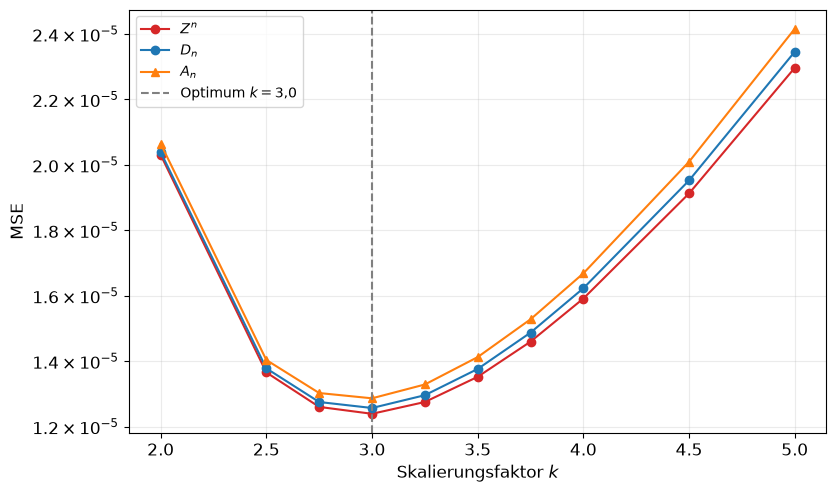

  -> alpha_u_curve.png / .pdf


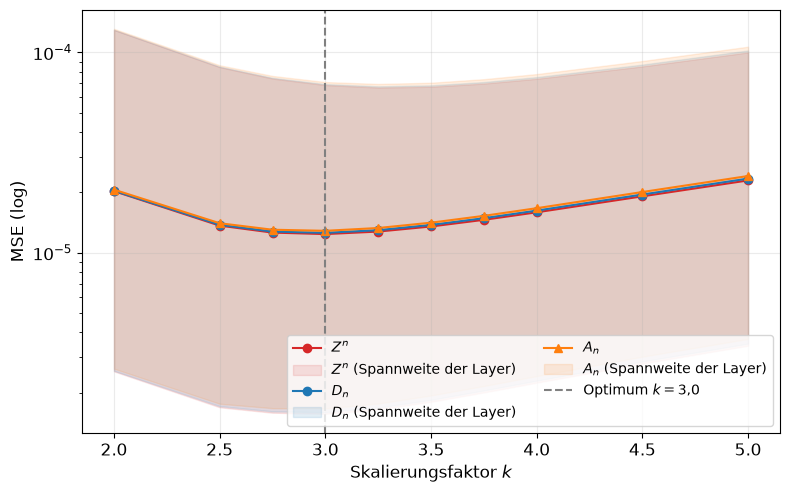

  -> alpha_u_curve_spannweite.png / .pdf


In [18]:
def plot_alpha():
    data = _load("alpha_results.json")

    labels = {"Z_n": "$Z^n$", "D_n": "$D_n$", "A_n": "$A_n$"}
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for meth in ("Z_n", "D_n", "A_n"):
        st = METHOD_STYLE[meth]
        ks = [row["k"] for row in data[meth]]
        mses = [row["mean_mse"] for row in data[meth]]
        ax.plot(ks, mses, color=st["color"], marker=st["marker"], ls=st["ls"],
                label=labels[meth])

    ax.axvline(3.0, color="gray", ls="--", label="Optimum $k = 3{,}0$")
    ax.set_xlabel("Skalierungsfaktor $k$")
    ax.set_ylabel("MSE")
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"${x*1e5:.1f}\\times10^{{-5}}$")
    )
    ax.legend()
    _save(fig, "alpha_u_curve")


def plot_alpha_spannweite():
    """Wie plot_alpha, zusaetzlich Min/Max-Spannweite ueber die Layer.
    y logarithmisch, weil die Spannweite ~2 Groessenordnungen ueberdeckt."""
    data = _load("alpha_results.json")

    labels = {"Z_n": "$Z^n$", "D_n": "$D_n$", "A_n": "$A_n$"}
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for meth in ("Z_n", "D_n", "A_n"):
        st = METHOD_STYLE[meth]
        ks = [row["k"] for row in data[meth]]
        mses = [row["mean_mse"] for row in data[meth]]
        lo = [row["min_mse"] for row in data[meth]]
        hi = [row["max_mse"] for row in data[meth]]
        ax.plot(ks, mses, color=st["color"], marker=st["marker"], ls=st["ls"],
                label=labels[meth])
        ax.fill_between(ks, lo, hi, color=st["color"], alpha=0.12,
                        label=f"{labels[meth]} (Spannweite der Layer)")

    ax.axvline(3.0, color="gray", ls="--", label="Optimum $k = 3{,}0$")
    ax.set_yscale("log")
    ax.set_xlabel("Skalierungsfaktor $k$")
    ax.set_ylabel("MSE (log)")
    ax.legend(ncol=2)
    _save(fig, "alpha_u_curve_spannweite")

plot_alpha()
plot_alpha_spannweite()

## Gitterdimension

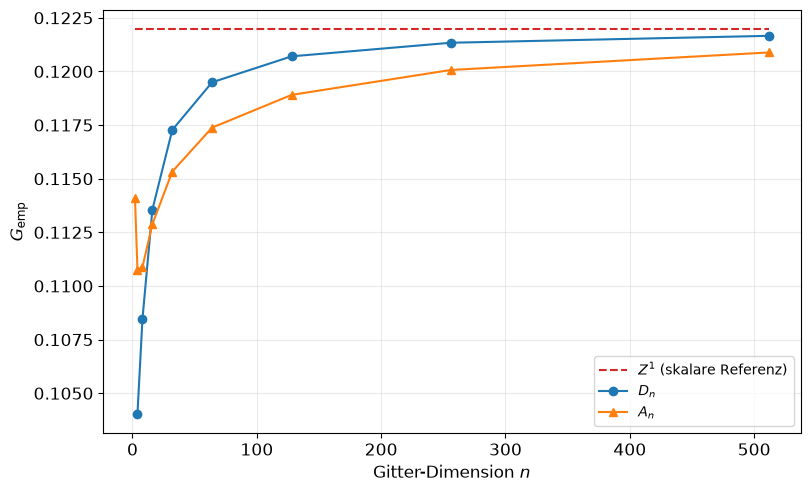

  -> dimension_nsm.png / .pdf


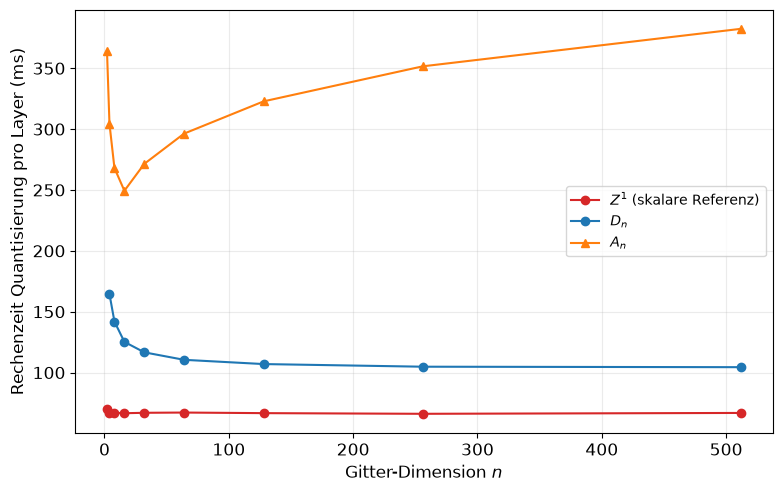

  -> dimension_zeit.png / .pdf


In [19]:
def plot_dimension_nsm():
    rows = _load("dimension_study_results.json")
    ns = [r["n"] for r in rows]
    d_rows = [r for r in rows if r["n"] != 2]     # D_n ohne n=2

    fig, ax = plt.subplots(figsize=(9, 5.5))
    z = METHOD_STYLE["Z_n"]
    d = METHOD_STYLE["D_n"]
    a = METHOD_STYLE["A_n"]
    ax.plot(ns, [r["G_Zn"] for r in rows], color=z["color"], ls="--",
            label="$Z^1$ (skalare Referenz)")
    ax.plot([r["n"] for r in d_rows], [r["G_Dn"] for r in d_rows],
            color=d["color"], marker=d["marker"],
            ls=d["ls"], label="$D_n$")
    ax.plot(ns, [r["G_An"] for r in rows], color=a["color"], marker=a["marker"],
            ls=a["ls"], label="$A_n$")

    ax.set_xlabel("Gitter-Dimension $n$")
    ax.set_ylabel("$G_{\\mathrm{emp}}$")
    ax.legend()
    _save(fig, "dimension_nsm")


def plot_dimension_zeit():
    rows = _load("dimension_study_results.json")
    ns = [r["n"] for r in rows]
    d_rows = [r for r in rows if r["n"] != 2]     # D_n ohne n=2

    fig, ax = plt.subplots(figsize=(9, 5.5))
    z = METHOD_STYLE["Z_n"]
    d = METHOD_STYLE["D_n"]
    a = METHOD_STYLE["A_n"]
    ax.plot(ns, [r["Zeit_Zn"] * 1000 for r in rows], color=z["color"],
            marker=z["marker"], ls=z["ls"], label="$Z^1$ (skalare Referenz)")
    ax.plot([r["n"] for r in d_rows], [r["Zeit_Dn"] * 1000 for r in d_rows],
            color=d["color"],
            marker=d["marker"], ls=d["ls"], label="$D_n$")
    ax.plot(ns, [r["Zeit_An"] * 1000 for r in rows], color=a["color"],
            marker=a["marker"], ls=a["ls"], label="$A_n$")

    ax.set_xlabel("Gitter-Dimension $n$")
    ax.set_ylabel("Rechenzeit Quantisierung pro Layer (ms)")
    ax.legend()
    _save(fig, "dimension_zeit")

plot_dimension_nsm()
plot_dimension_zeit()

## Bitrate

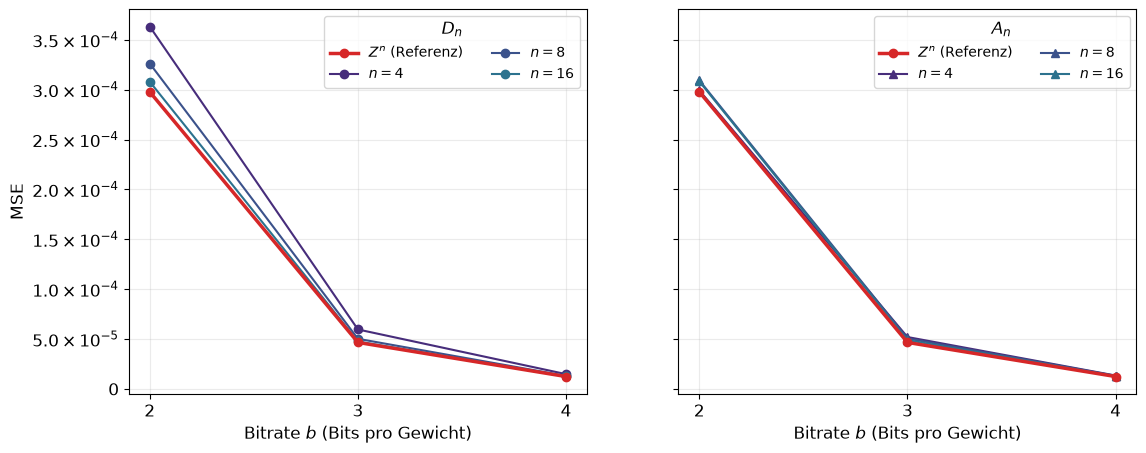

  -> bitrate_mse.png / .pdf


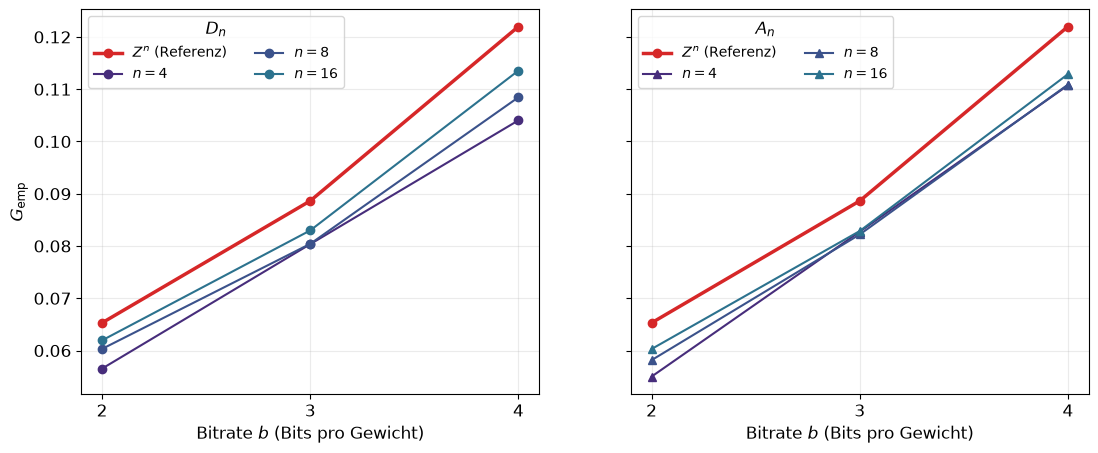

  -> bitrate_nsm.png / .pdf


In [20]:
def _plot_bitrate(fname_json, value_key, ylabel, out_name, log_scale=True, sci_fmt=False):
    records = _load(fname_json)
    bit_ticks = sorted({r["b"] for r in records})
    # In den Bitraten-Plots nur n=4/8/16 zeigen
    dims = sorted({r["n"] for r in records if r["method"] != "Z_n"} & {4, 8, 16})

    z_rows = sorted((r for r in records if r["method"] == "Z_n"),
                    key=lambda r: r["b"])
    z_b = [r["b"] for r in z_rows]
    z_v = [r[value_key] for r in z_rows]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, meth in zip(axes, ("D_n", "A_n")):
        st = METHOD_STYLE[meth]
        zst = METHOD_STYLE["Z_n"]
        ax.plot(z_b, z_v, color=zst["color"], marker=zst["marker"],
                ls=zst["ls"], lw=2.5, label="$Z^n$ (Referenz)", zorder=5)
        for n in dims:
            sub = sorted((r for r in records
                          if r["method"] == meth and r["n"] == n),
                         key=lambda r: r["b"])
            ax.plot([r["b"] for r in sub], [r[value_key] for r in sub],
                    color=DIM_COLOR[n], marker=st["marker"], ls=st["ls"],
                    label=f"$n={n}$")
        if log_scale:
            ax.set_yscale("log")
        if sci_fmt:
            ax.yaxis.set_major_formatter(ticker.FuncFormatter(_fmt_sci))
        ax.set_xticks(bit_ticks)
        ax.set_xlabel("Bitrate $b$ (Bits pro Gewicht)")
        ax.legend(title=f"${meth[0]}_n$", ncol=2)

    axes[0].set_ylabel(ylabel)
    _save(fig, out_name)


def plot_bitrate_mse():
    _plot_bitrate("bitrate_study_results.json", "mse",
                  "MSE", "bitrate_mse", log_scale=False, sci_fmt=True)


def plot_bitrate_nsm():
    _plot_bitrate("bitrate_study_nsm_results.json", "G_emp",
                  "$G_{\\mathrm{emp}}$", "bitrate_nsm", log_scale=False)

plot_bitrate_mse()
plot_bitrate_nsm()

## Perplexity

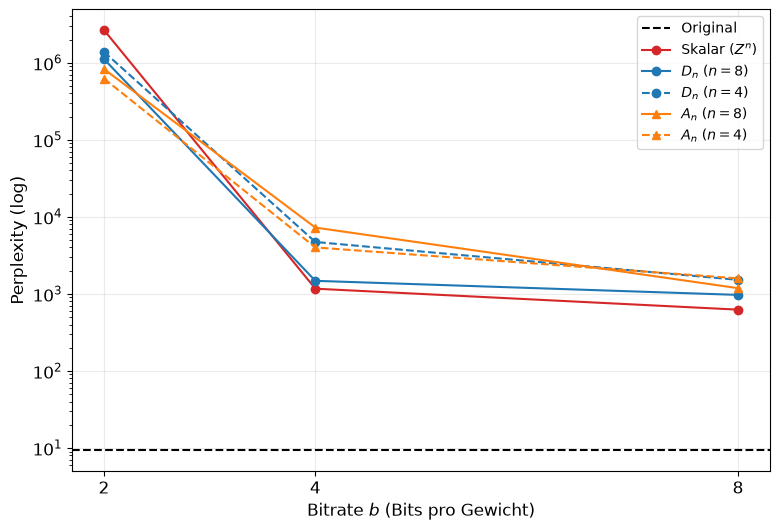

  -> perplexity_isorate.png / .pdf


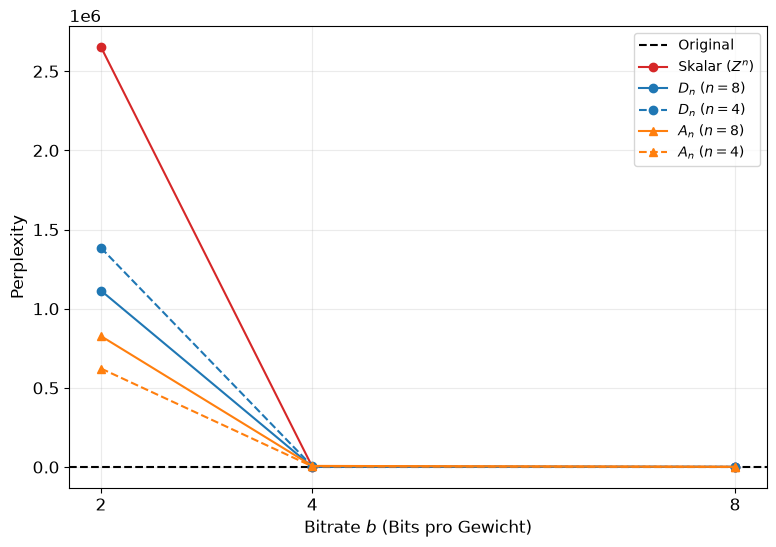

  -> perplexity_isorate_linear.png / .pdf


In [21]:
def _load_ppl_rows(fname):
    """Pandas-Spalten-JSON ({Spalte: {Zeilenindex: Wert}}) in Zeilen umwandeln."""
    data = _load(fname)
    idx = list(data["Methode"].keys())
    return [{col: data[col][i] for col in data} for i in idx]


def plot_perplexity():
    rows = _load_ppl_rows("ppl_results.json")

    # Deduplizieren (Original/Skalar sind in beiden Dateien identisch enthalten)
    seen, unique = set(), []
    for r in rows:
        key = (r["Methode"], r["n"], r["b"])
        if key not in seen:
            seen.add(key)
            unique.append(r)

    ppl_orig = next(r["PPL"] for r in unique if r["Methode"] == "Original")

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.axhline(ppl_orig, color=METHOD_STYLE["Original"]["color"],
               ls=METHOD_STYLE["Original"]["ls"], label="Original")

    # (Methode, n, Linienstil, Label) -- n=8 durchgezogen, n=4 gestrichelt
    curves = [
        ("Skalar", 1, "-",  "Skalar ($Z^n$)"),
        ("D_n",    8, "-",  "$D_n$ ($n=8$)"),
        ("D_n",    4, "--", "$D_n$ ($n=4$)"),
        ("A_n",    8, "-",  "$A_n$ ($n=8$)"),
        ("A_n",    4, "--", "$A_n$ ($n=4$)"),
    ]
    for meth, n, ls, label in curves:
        style_key = "Z_n" if meth == "Skalar" else meth
        st = METHOD_STYLE[style_key]
        sub = sorted((r for r in unique
                      if r["Methode"] == meth and r["n"] == n),
                     key=lambda r: r["b"])
        ax.plot([r["b"] for r in sub], [r["PPL"] for r in sub],
                color=st["color"], marker=st["marker"], ls=ls, label=label)

    ax.set_yscale("log")
    ax.set_xticks([2, 4, 8])
    ax.set_xlabel("Bitrate $b$ (Bits pro Gewicht)")
    ax.set_ylabel("Perplexity (log)")
    ax.legend()
    _save(fig, "perplexity_isorate")


def plot_perplexity_linear():
    rows = _load_ppl_rows("ppl_results.json")

    seen, unique = set(), []
    for r in rows:
        key = (r["Methode"], r["n"], r["b"])
        if key not in seen:
            seen.add(key)
            unique.append(r)

    ppl_orig = next(r["PPL"] for r in unique if r["Methode"] == "Original")

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.axhline(ppl_orig, color=METHOD_STYLE["Original"]["color"],
               ls=METHOD_STYLE["Original"]["ls"], label="Original")

    curves = [
        ("Skalar", 1, "-",  "Skalar ($Z^n$)"),
        ("D_n",    8, "-",  "$D_n$ ($n=8$)"),
        ("D_n",    4, "--", "$D_n$ ($n=4$)"),
        ("A_n",    8, "-",  "$A_n$ ($n=8$)"),
        ("A_n",    4, "--", "$A_n$ ($n=4$)"),
    ]
    for meth, n, ls, label in curves:
        style_key = "Z_n" if meth == "Skalar" else meth
        st = METHOD_STYLE[style_key]
        sub = sorted((r for r in unique
                      if r["Methode"] == meth and r["n"] == n),
                     key=lambda r: r["b"])
        ax.plot([r["b"] for r in sub], [r["PPL"] for r in sub],
                color=st["color"], marker=st["marker"], ls=ls, label=label)

    ax.set_xticks([2, 4, 8])
    ax.set_xlabel("Bitrate $b$ (Bits pro Gewicht)")
    ax.set_ylabel("Perplexity")
    ax.legend()
    _save(fig, "perplexity_isorate_linear")


# ---------------------------------------------------------------------------

plot_perplexity()
plot_perplexity_linear()